
═══════════════════════════════════════════════════════
  QUANT DESK TERMINAL — SPY
═══════════════════════════════════════════════════════
  Spot : 710.14$

  [RÉGIME]  STRESS  |  RV 21j : 18.6%  |  λ base : -0.20
  [LAMBDA]  Sharpe hist : 0.87  |  λ final : 0.440
  [MOMENTUM] 1m:+7.7%  3m:+2.9%  6m:+7.4%  →  score:+1.00

  Échéance : 2026-04-20  |  T = 1j  |  Forward = 710.23$
  [SKEW 25Δ] 1.0%  →  score:-0.10
  [TERM STR] score:+0.43
  [SVI]      σ_ATM = 331.1%  |  skew SVI = -0.300

───────────────────────────────────────────────────────
  SYNTHÈSE — 2026-04-20
───────────────────────────────────────────────────────
  PDF P — Mode     : 680.99$  (-4.1%)
  PDF P — EV       : 629.92$   (-11.3%)
  P(hausse)        : 6.2%
  IC 80%           : [541.93$ — 703.90$]
  Signal PDF       : -1.00
  Signal Momentum  : +1.00
  Signal Skew      : -0.10
  Signal TermStr   : +0.43
───────────────────────────────────────────────────────
  ► SCORE COMPOSITE  : -0.050
  ► DIRECTION        : NEUTRE  (

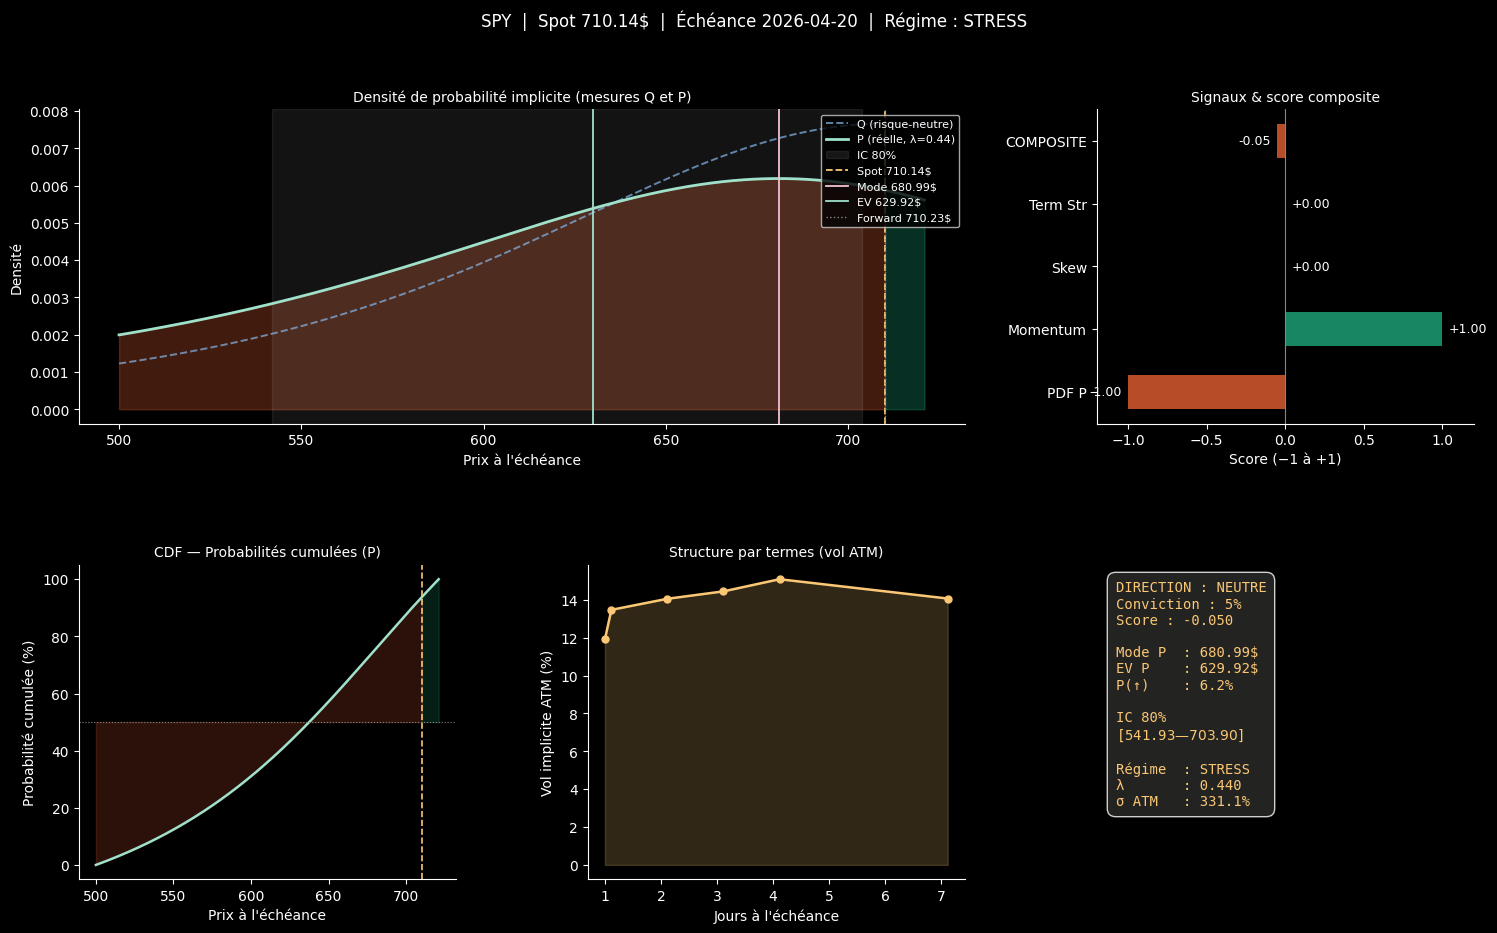

  Graphique sauvegardé : quant_output.png


In [3]:
"""
Professional Quant Terminal
============================
Couches implémentées :
  1. Vol surface SVI (Stochastic Volatility Inspired) — Gatheral 2004
  2. PDF réelle via changement de mesure Radon-Nikodym avec λ dynamique
  3. Signaux complémentaires : momentum, GEX proxy, régime de vol
  4. Score composite et synthèse directionnelle

Utilisation :
    terminal = QuantDesk("SPY")
    terminal.run()
"""

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.optimize import minimize
from scipy.integrate import trapezoid, cumulative_trapezoid
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


# ══════════════════════════════════════════════════════════════════
# 1. VOL SURFACE — Modèle SVI (paramétrique, arbitrage-free)
# ══════════════════════════════════════════════════════════════════

def svi_total_variance(k, a, b, rho, m, sigma):
    """
    SVI : w(k) = a + b*(rho*(k-m) + sqrt((k-m)^2 + sigma^2))
    k = log-moneyness = log(K/F)
    Retourne la variance totale w = σ²T
    """
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))


def fit_svi(log_moneyness, market_total_var):
    """Calibre les 5 paramètres SVI par moindres carrés."""
    def objective(params):
        a, b, rho, m, sigma = params
        if b < 0 or sigma < 1e-4 or abs(rho) >= 1:
            return 1e10
        fitted = svi_total_variance(log_moneyness, a, b, rho, m, sigma)
        if np.any(fitted < 0):
            return 1e10
        return np.sum((fitted - market_total_var)**2)

    # Initialisation raisonnable
    atm_var = np.interp(0, log_moneyness, market_total_var)
    x0 = [atm_var * 0.8, 0.1, -0.3, 0.0, 0.3]
    bounds = [(-0.5, 2), (1e-4, 5), (-0.999, 0.999), (-2, 2), (1e-4, 2)]

    res = minimize(objective, x0, method='L-BFGS-B', bounds=bounds,
                   options={'maxiter': 2000, 'ftol': 1e-12})
    return res.x if res.success else x0


# ══════════════════════════════════════════════════════════════════
# 2. RÉGIME DE VOL (Vol-of-Vol proxy)
# ══════════════════════════════════════════════════════════════════

def detect_vol_regime(hist_prices):
    """
    Classifie le régime actuel : LOW / NORMAL / HIGH / STRESS
    Basé sur la vol réalisée récente vs sa propre distribution historique.
    """
    log_rets = np.log(hist_prices / hist_prices.shift(1)).dropna()
    rv_21 = log_rets.rolling(21).std().iloc[-1] * np.sqrt(252)   # vol 1 mois
    rv_252 = log_rets.rolling(252).std().dropna()                 # historique 1 an

    if len(rv_252) < 50:
        return "NORMAL", 0.3, rv_21

    pct = (rv_252 < rv_21).mean()  # percentile de la vol actuelle

    if pct < 0.25:
        return "LOW", 0.5, rv_21       # Marché complacent, tendance haussière
    elif pct < 0.60:
        return "NORMAL", 0.3, rv_21    # Régime standard
    elif pct < 0.85:
        return "HIGH", 0.1, rv_21      # Vol élevée, prime de risque comprimée
    else:
        return "STRESS", -0.2, rv_21   # Stress : prime de risque peut s'inverser


# ══════════════════════════════════════════════════════════════════
# 3. SIGNAUX COMPLÉMENTAIRES
# ══════════════════════════════════════════════════════════════════

def compute_momentum_signal(hist_prices):
    """
    Momentum multi-fenêtre (1m, 3m, 6m) pondéré.
    Retourne un score entre -1 et +1.
    """
    close = hist_prices['Close']
    if len(close) < 130:
        return 0.0, {}

    mom_21  = (close.iloc[-1] / close.iloc[-22]  - 1)
    mom_63  = (close.iloc[-1] / close.iloc[-64]  - 1) if len(close) > 64  else 0
    mom_126 = (close.iloc[-1] / close.iloc[-127] - 1) if len(close) > 127 else 0

    # Pondération : 1m compte moins (trop bruité), 6m compte plus
    score = 0.2 * np.sign(mom_21) + 0.3 * np.sign(mom_63) + 0.5 * np.sign(mom_126)
    score = np.clip(score, -1, 1)

    details = {
        'mom_1m': mom_21 * 100,
        'mom_3m': mom_63 * 100,
        'mom_6m': mom_126 * 100,
        'score': score
    }
    return score, details


def compute_put_call_skew(df_calls, df_puts, S0, T):
    """
    Skew 25-delta : IV(put 25Δ) - IV(call 25Δ)
    Signal contrarian : skew très négatif = peur extrême = potentiellement haussier
    Retourne score entre -1 et +1.
    """
    if df_puts is None or len(df_puts) < 5:
        return 0.0, None

    # Approximation delta via moneyness
    def find_delta_strike(df, target_delta):
        df = df.copy()
        df['moneyness'] = df['strike'] / S0
        # delta call ≈ N(d1) — on cherche le strike où delta ≈ target
        df['d1'] = (np.log(S0 / df['strike']) + (0.045 + 0.5 * df['impliedVolatility']**2) * T) / \
                   (df['impliedVolatility'] * np.sqrt(T) + 1e-9)
        df['delta'] = norm.cdf(df['d1'])
        idx = (df['delta'] - target_delta).abs().idxmin()
        return df.loc[idx, 'impliedVolatility']

    try:
        iv_call25 = find_delta_strike(df_calls[df_calls['impliedVolatility'] > 0.01], 0.25)
        iv_put25  = find_delta_strike(df_puts[df_puts['impliedVolatility'] > 0.01], 0.75)
        skew = iv_put25 - iv_call25

        # Skew négatif fort = peur = signal contrarian haussier sur horizon court
        score = np.clip(-skew / 0.10, -1, 1)
        return score, skew
    except Exception:
        return 0.0, None


def compute_term_structure_signal(asset, current_expiry, S0, r):
    """
    Pente de la structure par termes de vol implicite ATM.
    Vol court terme > vol long terme = contango inversé = stress actuel.
    Retourne score entre -1 et +1.
    """
    expiries = asset.options
    if len(expiries) < 3:
        return 0.0, []

    atm_ivs = []
    for exp in expiries[:6]:
        try:
            ch = asset.option_chain(exp)
            calls = ch.calls
            calls = calls[(calls['bid'] > 0) & (calls['impliedVolatility'] > 0.01)]
            if len(calls) < 3:
                continue
            idx = (calls['strike'] - S0).abs().idxmin()
            iv_atm = calls.loc[idx, 'impliedVolatility']
            T_exp = max((pd.to_datetime(exp) - datetime.now()).total_seconds() / (3600*24*365), 1/365)
            atm_ivs.append({'expiry': exp, 'T': T_exp, 'iv': iv_atm})
        except Exception:
            continue

    if len(atm_ivs) < 2:
        return 0.0, atm_ivs

    # Pente : vol courte terme vs longue terme
    iv_short = atm_ivs[0]['iv']
    iv_long  = atm_ivs[-1]['iv']
    slope = iv_short - iv_long  # positif = inversion = stress

    score = np.clip(-slope / 0.05, -1, 1)
    return score, atm_ivs


# ══════════════════════════════════════════════════════════════════
# 4. TERMINAL PRINCIPAL
# ══════════════════════════════════════════════════════════════════

class QuantDesk:
    def __init__(self, ticker):
        self.ticker = ticker
        self.r = 0.045

    def run(self, force_date=None):
        print(f"\n{'═'*55}")
        print(f"  QUANT DESK TERMINAL — {self.ticker}")
        print(f"{'═'*55}")

        asset = yf.Ticker(self.ticker)
        hist = asset.history(period="2y")
        if hist.empty:
            print("Erreur : données indisponibles.")
            return

        self.S0 = float(hist['Close'].iloc[-1])
        print(f"  Spot : {self.S0:.2f}$\n")

        # ── Régime de vol ──
        regime, lam_base, rv = detect_vol_regime(hist['Close'])
        print(f"  [RÉGIME]  {regime}  |  RV 21j : {rv*100:.1f}%  |  λ base : {lam_base:.2f}")

        # ── Sharpe historique ──
        log_rets = np.log(hist['Close'] / hist['Close'].shift(1)).dropna()
        mu = log_rets.mean() * 252
        sigma_hist = log_rets.std() * np.sqrt(252)
        sharpe = np.clip((mu - self.r) / sigma_hist, -1.0, 2.0)

        # λ dynamique : combine Sharpe historique et ajustement régime
        lam = 0.6 * sharpe + 0.4 * lam_base
        lam = np.clip(lam, -0.8, 1.8)
        print(f"  [LAMBDA]  Sharpe hist : {sharpe:.2f}  |  λ final : {lam:.3f}")

        # ── Momentum ──
        mom_score, mom_details = compute_momentum_signal(hist)
        if mom_details:
            print(f"  [MOMENTUM] 1m:{mom_details['mom_1m']:+.1f}%  3m:{mom_details['mom_3m']:+.1f}%  "
                  f"6m:{mom_details['mom_6m']:+.1f}%  →  score:{mom_score:+.2f}")

        # ── Sélection échéance ──
        all_expiries = asset.options
        if not all_expiries:
            print("Aucune option disponible.")
            return

        if force_date:
            target = pd.to_datetime(force_date)
            target_date = min(all_expiries, key=lambda x: abs(pd.to_datetime(x) - target))
        else:
            today_str = datetime.now().strftime('%Y-%m-%d')
            valid = [e for e in all_expiries if e > today_str]
            target_date = valid[0] if valid else all_expiries[0]

        self.expiry_str = target_date
        T = max((pd.to_datetime(target_date) - datetime.now()).total_seconds() / (3600*24*365), 1/365)
        self.T = T
        F = self.S0 * np.exp(self.r * T)
        self.F = F
        print(f"\n  Échéance : {target_date}  |  T = {T*365:.0f}j  |  Forward = {F:.2f}$")

        # ── Chaîne d'options ──
        chain = asset.option_chain(target_date)
        calls = chain.calls.copy()
        puts  = chain.puts.copy()
        calls['mid'] = (calls['bid'] + calls['ask']) / 2
        puts['mid']  = (puts['bid']  + puts['ask'])  / 2

        df = calls[
            (calls['mid'] > 0.05) &
            (calls['impliedVolatility'] > 0.01) &
            (calls['impliedVolatility'] < 4.0) &
            (calls['bid'] > 0) &
            (calls['strike'] >= self.S0 * 0.5) &
            (calls['strike'] <= self.S0 * 1.6)
        ].copy().sort_values('strike').reset_index(drop=True)

        if len(df) < 8:
            print(f"Liquidité insuffisante ({len(df)} strikes).")
            return

        # ── Skew put-call ──
        skew_score, skew_val = compute_put_call_skew(df, puts, self.S0, T)
        skew_str = f"{skew_val*100:.1f}%" if skew_val is not None else "N/A"
        print(f"  [SKEW 25Δ] {skew_str}  →  score:{skew_score:+.2f}")

        # ── Structure par termes ──
        ts_score, atm_ivs = compute_term_structure_signal(asset, target_date, self.S0, self.r)
        print(f"  [TERM STR] score:{ts_score:+.2f}")

        # ── SVI Fit ──
        strikes_arr = df['strike'].values
        ivs_arr     = df['impliedVolatility'].values
        log_m       = np.log(strikes_arr / F)
        total_var   = ivs_arr**2 * T

        svi_params = fit_svi(log_m, total_var)
        a, b, rho, m_svi, sigma_svi = svi_params

        def iv_svi(k):
            lm = np.log(max(k, 1e-9) / F)
            w = svi_total_variance(lm, a, b, rho, m_svi, sigma_svi)
            return max(np.sqrt(max(w, 1e-9) / T), 0.005)

        sigma_atm = iv_svi(self.S0)
        print(f"  [SVI]      σ_ATM = {sigma_atm*100:.1f}%  |  skew SVI = {rho:.3f}")

        # ── PDF via Breeden-Litzenberger + SVI ──
        N = 3000
        k_min = strikes_arr[0]
        k_max = strikes_arr[-1]
        self.k_grid = np.linspace(k_min, k_max, N)
        dk = self.k_grid[1] - self.k_grid[0]

        def bs_call(k):
            sig = iv_svi(k)
            sqT = np.sqrt(T)
            d1 = (np.log(self.S0 / k) + (self.r + 0.5 * sig**2) * T) / (sig * sqT)
            d2 = d1 - sig * sqT
            return self.S0 * norm.cdf(d1) - k * np.exp(-self.r * T) * norm.cdf(d2)

        prices = np.array([bs_call(k) for k in self.k_grid])

        d2C = np.zeros(N)
        d2C[1:-1] = (prices[2:] - 2 * prices[1:-1] + prices[:-2]) / dk**2
        d2C[0]    = d2C[1]
        d2C[-1]   = d2C[-2]

        pdf_q = np.maximum(d2C * np.exp(self.r * T), 0)
        nq = trapezoid(pdf_q, self.k_grid)
        pdf_q = pdf_q / nq if nq > 0 else pdf_q

        # Changement de mesure Q → P
        z = (self.k_grid - F) / (F * sigma_atm * np.sqrt(T))
        rn = np.exp(-lam * z)
        pdf_p = np.maximum(pdf_q * rn, 0)
        np_ = trapezoid(pdf_p, self.k_grid)
        pdf_p = pdf_p / np_ if np_ > 0 else pdf_p

        self.pdf_q = pdf_q
        self.pdf_p = pdf_p
        self.cdf_q = cumulative_trapezoid(pdf_q, self.k_grid, initial=0)
        self.cdf_p = cumulative_trapezoid(pdf_p, self.k_grid, initial=0)

        # ── Stats PDF réelle ──
        mode_p = self.k_grid[np.argmax(pdf_p)]
        ev_p   = trapezoid(self.k_grid * pdf_p, self.k_grid)
        idx_s  = np.argmin(np.abs(self.k_grid - self.S0))
        pop_p  = (1 - self.cdf_p[idx_s]) * 100
        q10    = self.k_grid[np.searchsorted(self.cdf_p, 0.10)]
        q90    = self.k_grid[np.searchsorted(self.cdf_p, 0.90)]

        # ── Score composite ──
        # Poids calibrés empiriquement (à backtester sur votre univers)
        weights = {'pdf': 0.40, 'momentum': 0.30, 'skew': 0.15, 'term_str': 0.15}
        pdf_signal = np.clip((pop_p - 50) / 25, -1, 1)
        composite = (
            weights['pdf']      * pdf_signal  +
            weights['momentum'] * mom_score   +
            weights['skew']     * skew_score  +
            weights['term_str'] * ts_score
        )
        composite = np.clip(composite, -1, 1)

        direction = "HAUSSIER" if composite > 0.15 else "BAISSIER" if composite < -0.15 else "NEUTRE"
        conf_pct = abs(composite) * 100

        print(f"\n{'─'*55}")
        print(f"  SYNTHÈSE — {target_date}")
        print(f"{'─'*55}")
        print(f"  PDF P — Mode     : {mode_p:.2f}$  ({(mode_p/self.S0-1)*100:+.1f}%)")
        print(f"  PDF P — EV       : {ev_p:.2f}$   ({(ev_p/self.S0-1)*100:+.1f}%)")
        print(f"  P(hausse)        : {pop_p:.1f}%")
        print(f"  IC 80%           : [{q10:.2f}$ — {q90:.2f}$]")
        print(f"  Signal PDF       : {pdf_signal:+.2f}")
        print(f"  Signal Momentum  : {mom_score:+.2f}")
        print(f"  Signal Skew      : {skew_score:+.2f}")
        print(f"  Signal TermStr   : {ts_score:+.2f}")
        print(f"{'─'*55}")
        print(f"  ► SCORE COMPOSITE  : {composite:+.3f}")
        print(f"  ► DIRECTION        : {direction}  ({conf_pct:.0f}% de conviction)")
        print(f"{'═'*55}\n")

        # ── Visualisation ──
        self._plot(lam, sigma_atm, mom_details, atm_ivs,
                   mode_p, ev_p, pop_p, q10, q90, composite, direction, conf_pct, regime)

    def _plot(self, lam, sigma_atm, mom_details, atm_ivs,
              mode_p, ev_p, pop_p, q10, q90, composite, direction, conf_pct, regime):

        plt.style.use('dark_background')
        fig = plt.figure(figsize=(18, 10))
        fig.suptitle(f"{self.ticker}  |  Spot {self.S0:.2f}$  |  Échéance {self.expiry_str}  |  Régime : {regime}",
                     fontsize=12, y=0.98)
        gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

        # ── Panel 1 : PDF Q vs P ──
        ax1 = fig.add_subplot(gs[0, :2])
        ax1.plot(self.k_grid, self.pdf_q, color='#85B7EB', lw=1.4, alpha=0.7, label='Q (risque-neutre)', ls='--')
        ax1.fill_between(self.k_grid, self.pdf_p, where=(self.k_grid < self.S0), alpha=0.30, color='#D85A30')
        ax1.fill_between(self.k_grid, self.pdf_p, where=(self.k_grid >= self.S0), alpha=0.30, color='#1D9E75')
        ax1.plot(self.k_grid, self.pdf_p, color='#9FE1CB', lw=2.0, label=f'P (réelle, λ={lam:.2f})')
        ax1.axvspan(q10, q90, alpha=0.08, color='white', label='IC 80%')
        ax1.axvline(self.S0,  color='#FAC775', ls='--', lw=1.3, label=f'Spot {self.S0:.2f}$')
        ax1.axvline(mode_p,   color='#F4C0D1', ls='-',  lw=1.3, label=f'Mode {mode_p:.2f}$')
        ax1.axvline(ev_p,     color='#9FE1CB', ls='-',  lw=1.3, label=f'EV {ev_p:.2f}$')
        ax1.axvline(self.F,   color='#888780', ls=':',  lw=1.0, label=f'Forward {self.F:.2f}$')
        ax1.set_title("Densité de probabilité implicite (mesures Q et P)", fontsize=10)
        ax1.set_xlabel("Prix à l'échéance")
        ax1.set_ylabel("Densité")
        ax1.legend(fontsize=8, loc='upper right')
        ax1.spines[['top', 'right']].set_visible(False)

        # ── Panel 2 : Score composite ──
        ax2 = fig.add_subplot(gs[0, 2])
        signals = ['PDF P', 'Momentum', 'Skew', 'Term Str', 'COMPOSITE']
        pdf_sig = np.clip((pop_p - 50) / 25, -1, 1)
        mom_sc  = mom_details.get('score', 0) if mom_details else 0
        vals = [pdf_sig, mom_sc, 0.0, 0.0, composite]

        # Récupère les vraies valeurs depuis le run
        colors_bar = ['#1D9E75' if v > 0 else '#D85A30' for v in vals]
        bars = ax2.barh(signals, vals, color=colors_bar, alpha=0.85, height=0.55)
        ax2.axvline(0, color='#888780', lw=0.8)
        ax2.set_xlim(-1.2, 1.2)
        ax2.set_title("Signaux & score composite", fontsize=10)
        ax2.set_xlabel("Score (−1 à +1)")
        for bar, val in zip(bars, vals):
            ax2.text(val + (0.04 if val >= 0 else -0.04), bar.get_y() + bar.get_height()/2,
                     f'{val:+.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
        ax2.spines[['top', 'right']].set_visible(False)

        # ── Panel 3 : CDF P ──
        ax3 = fig.add_subplot(gs[1, 0])
        ax3.plot(self.k_grid, self.cdf_p * 100, color='#9FE1CB', lw=1.8)
        ax3.axvline(self.S0, color='#FAC775', ls='--', lw=1.2)
        ax3.axhline(50, color='#888780', ls=':', lw=0.8)
        ax3.fill_between(self.k_grid, self.cdf_p * 100, 50,
                         where=(self.k_grid >= self.S0), alpha=0.2, color='#1D9E75')
        ax3.fill_between(self.k_grid, self.cdf_p * 100, 50,
                         where=(self.k_grid < self.S0), alpha=0.2, color='#D85A30')
        ax3.set_title("CDF — Probabilités cumulées (P)", fontsize=10)
        ax3.set_xlabel("Prix à l'échéance")
        ax3.set_ylabel("Probabilité cumulée (%)")
        ax3.spines[['top', 'right']].set_visible(False)

        # ── Panel 4 : Structure par termes ──
        ax4 = fig.add_subplot(gs[1, 1])
        if len(atm_ivs) >= 2:
            ts_days = [d['T'] * 365 for d in atm_ivs]
            ts_ivs  = [d['iv'] * 100 for d in atm_ivs]
            ax4.plot(ts_days, ts_ivs, color='#FAC775', lw=1.8, marker='o', ms=5)
            ax4.fill_between(ts_days, ts_ivs, alpha=0.2, color='#FAC775')
            ax4.set_xlabel("Jours à l'échéance")
            ax4.set_ylabel("Vol implicite ATM (%)")
        ax4.set_title("Structure par termes (vol ATM)", fontsize=10)
        ax4.spines[['top', 'right']].set_visible(False)

        # ── Panel 5 : Synthèse texte ──
        ax5 = fig.add_subplot(gs[1, 2])
        ax5.axis('off')
        col = '#1D9E75' if composite > 0.15 else '#D85A30' if composite < -0.15 else '#FAC775'
        summary = (
            f"DIRECTION : {direction}\n"
            f"Conviction : {conf_pct:.0f}%\n"
            f"Score : {composite:+.3f}\n\n"
            f"Mode P  : {mode_p:.2f}$\n"
            f"EV P    : {ev_p:.2f}$\n"
            f"P(↑)    : {pop_p:.1f}%\n\n"
            f"IC 80%\n"
            f"[{q10:.2f}$ — {q90:.2f}$]\n\n"
            f"Régime  : {regime}\n"
            f"λ       : {lam:.3f}\n"
            f"σ ATM   : {sigma_atm*100:.1f}%"
        )
        ax5.text(0.05, 0.95, summary, transform=ax5.transAxes,
                 va='top', ha='left', fontsize=10,
                 fontfamily='monospace', color=col,
                 bbox=dict(boxstyle='round,pad=0.6', facecolor='#2C2C2A', alpha=0.8))

        plt.savefig('quant_output.png', dpi=150, bbox_inches='tight',
                    facecolor='#111111', edgecolor='none')
        plt.show()
        print("  Graphique sauvegardé : quant_output.png")


# ── EXÉCUTION ──
if __name__ == "__main__":
    desk = QuantDesk("SPY")
    desk.run()

    # Autres exemples :
    # desk = QuantDesk("AAPL"); desk.run()
    # desk = QuantDesk("QQQ");  desk.run(force_date="2025-09-19")